In [1]:
# 启用交互式后端
%matplotlib widget

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体支持
plt.rcParams.update({
    "font.sans-serif": ["PingFang SC"],
    "axes.unicode_minus": False,
    "figure.dpi": 100
})

def reset():
    plt.close("all")

# Seaborn 全局样式
sns.set_theme(style="whitegrid", font="PingFang SC")

df = pd.read_csv("../linking_clean.csv")
df.head()

df_clean = df.dropna(subset=["薪资(k)"]).copy()


,昵称,学历,城市,经验(年),薪资(k),毕业年份,备注
0,Map,本科,北京,0.0,NaN,2026.0,NaN
1,yanni*,本科,杭州,8.0,28.0,NaN,新能源企业前端-->产品-->销售-->售前
2,边牧*,本科,长沙,5.0,9.0,NaN,离职，空窗期2年，北京17k，React，Flutter
3,决堤*,本科,北京,0.0,9.0,2025.0,被辞退
4,月亮*,大专,济南,3.0,9.0,NaN,NaN


# 用 Seaborn 分析前端开发者薪资数据

本节课通过分析一份前端开发者的薪资调研数据，一边做分析一边熟悉 **Seaborn**。

Seaborn 是建立在 Matplotlib 之上的高级统计可视化库，
特点是**用简洁的代码就能生成美观且有统计意义的图表**。

**本节课目标**：掌握 Seaborn 的核心图类型——分布图、箱线图、散点图、
回归图、分类汇总图、热力图等，并能结合实际数据做探索性分析。

---

## 1. 薪资分布 — 单变量分析

先用 `histplot` 和 `kdeplot` 看薪资的整体分布形态。

`histplot` — 直方图，展示数据在各区间的频次。

`kdeplot` — 核密度估计，平滑地展示概率密度。

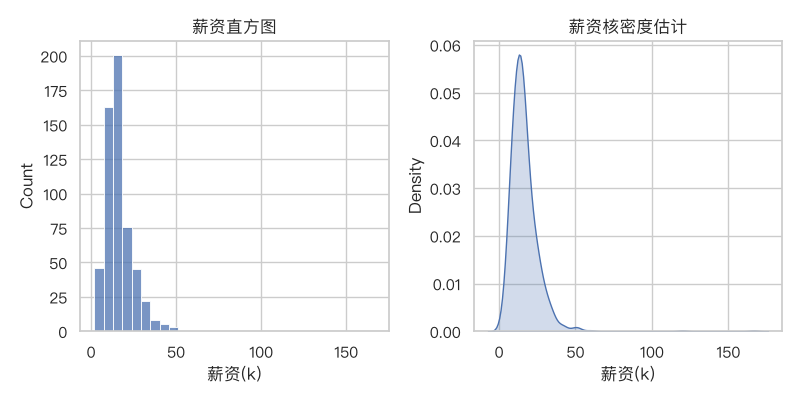

In [6]:
reset()
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# 直方图
sns.histplot(data=df_clean, x="薪资(k)", bins=30, ax=axes[0])
axes[0].set_title("薪资直方图")

# 核密度估计
sns.kdeplot(data=df_clean, x="薪资(k)", fill=True, ax=axes[1])
axes[1].set_title("薪资核密度估计")

# ax = axes[0]
# for patch in ax.patches:
#     height = patch.get_height()
#     if height > 0:  # 避免标注空柱子
#         ax.text(
#             patch.get_x() + patch.get_width()/2,  # X 坐标：柱子中间
#             height,                               # Y 坐标：柱子顶部
#             f'{int(height)}',                     # 显示内容
#             ha='center', va='bottom',             # 水平居中，垂直在底部上方
#             fontsize=8
#         )

plt.tight_layout()

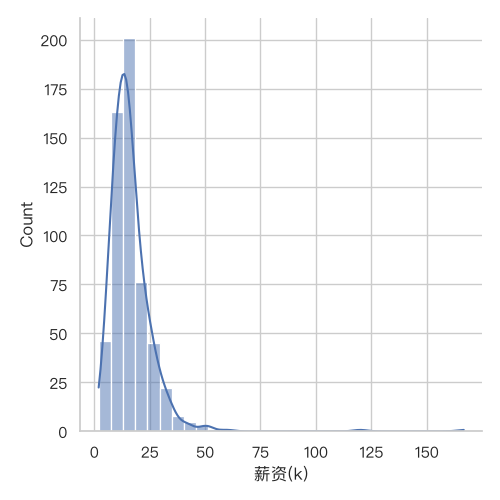

In [7]:
reset()
sns.displot(data=df_clean, x="薪资(k)",  kde=True, bins=30)

---

## 2. 学历与薪资 — 分类对比

用 `boxplot` 和 `violinplot` 对比不同学历的薪资分布。

`boxplot` — 箱线图，展示中位数、四分位数、异常值。

`violinplot` — 小提琴图，在箱线图基础上叠加了分布形状。

In [8]:
df['学历'].value_counts()

学历
本科    387
大专    210
硕士     36
高中     23
初中     12
中专      4
小学      1
Name: count, dtype: int64

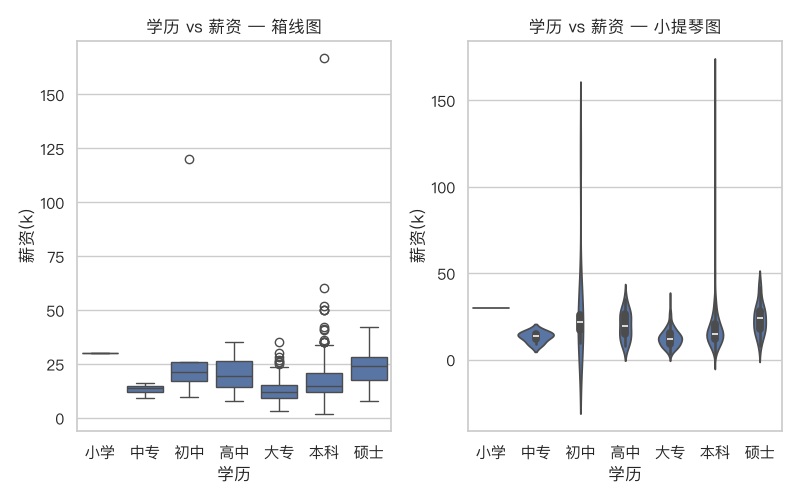

In [9]:
reset()
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# 箱线图
sns.boxplot(data=df_clean, x="学历", y="薪资(k)",
            order=["小学","中专", "初中", "高中", "大专", "本科", "硕士"], 
            ax=axes[0])
axes[0].set_title("学历 vs 薪资 — 箱线图")

# 小提琴图
sns.violinplot(data=df_clean, x="学历", y="薪资(k)",
               order=["小学","中专", "初中", "高中", "大专", "本科", "硕士"], 
               ax=axes[1])
axes[1].set_title("学历 vs 薪资 — 小提琴图")

fig.tight_layout()

Text(0.5, 1.0, '学历 vs 薪资均值')

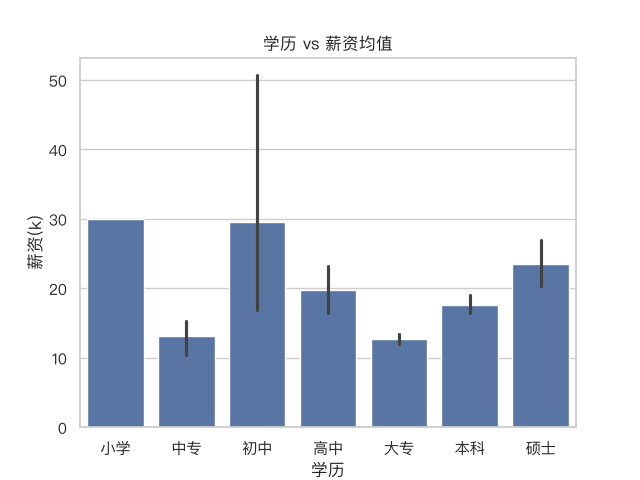

In [10]:
reset()
# barplot 默认显示均值 + 置信区间
sns.barplot(data=df_clean, x="学历", y="薪资(k)",
            order=["小学","中专", "初中", "高中", "大专", "本科", "硕士"])
plt.title("学历 vs 薪资均值")

---

## 3. 经验与薪资 — 回归分析

`scatterplot` 看散点分布，`regplot` 自动添加回归线，直观判断工作年限对薪资的影响。

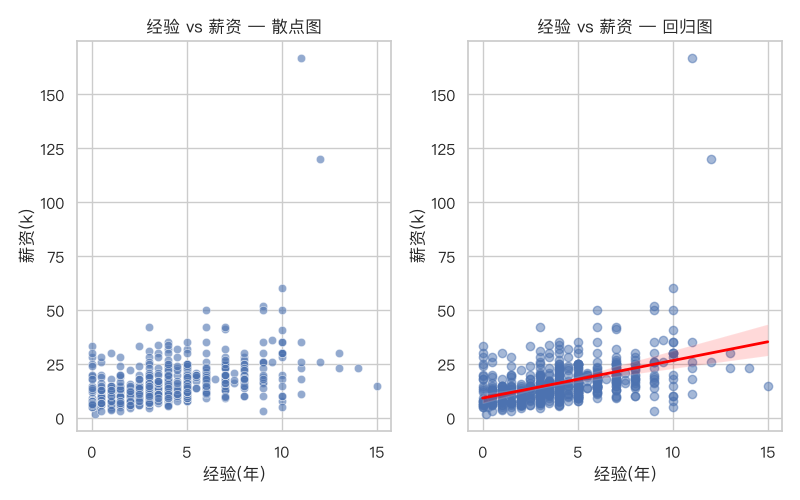

In [11]:
reset()
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# 散点图
sns.scatterplot(data=df_clean, x="经验(年)", y="薪资(k)", alpha=0.6, ax=axes[0])
axes[0].set_title("经验 vs 薪资 — 散点图")

# 添加回归线
sns.regplot(data=df_clean, x="经验(年)", y="薪资(k)",
            scatter_kws={"alpha": 0.5}, 
            line_kws={"color": "red", "linewidth": 2},
            ax=axes[1])
axes[1].set_title("经验 vs 薪资 — 回归图")

plt.tight_layout()